# Post-transcriptional regulation in breast cancer (CPTAC-BRCA)

**Question.** For each gene, how tightly does protein abundance track its mRNA level
across patients? Genes where protein is poorly explained by mRNA are candidates for
*post-transcriptional regulation* (translation, protein degradation, RNA stability).

**Data.** Matched transcriptomics and proteomics for the same breast-tumor samples,
from the public CPTAC-BRCA cohort (`cptac` package).

**Approach.**
1. Load and align mRNA and protein for the same patients and genes.
2. Filter poorly measured proteins, standardize each gene across samples.
3. Rank genes by mRNA–protein correlation (Spearman) — the core result.
4. Use the per-sample protein-to-RNA deviation (PTR) as a complementary, patient-level signal.

## Setup

In [1]:
import cptac
import pandas as pd
import matplotlib.pyplot as plt
from importlib.metadata import version
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

print("cptac version:", version("cptac"))

cptac version: 1.5.14


# 1 - Load the data

In [2]:
brca = cptac.Brca()
brca.list_data_sources()

,Data type,Available sources
0,CNV,"[bcm, washu]"
1,miRNA,[bcm]
2,phosphoproteomics,"[bcm, umich]"
3,proteomics,"[bcm, umich]"
4,transcriptomics,"[bcm, broad, washu]"
5,ancestry_prediction,[harmonized]
6,somatic_mutation,"[harmonized, washu]"
7,clinical,[mssm]
8,follow-up,[mssm]
9,medical_history,[mssm]


## Transcriptomics (mRNA)
We load the BRCA object and pull transcriptomics (mRNA) and proteomics from the
`bcm` source. 
Rows are tumor samples, columns are genes; each value is an mRNA abundance measurement. We use bcm for both mRNA and protein so the two tables share the same processing conventions.

In [3]:
rna = brca.get_transcriptomics(source="bcm")
print("Shape :", rna.shape[0], "Patients and", rna.shape[1], "genes")
rna.head()

F:\BD\ptr-proteogenomics-brca\.venv\Lib\site-packages\cptac\cancers\bcm\bcmbrca.py:87: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  transcript = transcript.reset_index()


Shape : 133 Patients and 60591 genes


Name,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2ML1-AS2,A2MP1,A3GALT2,...,ZXDB,ZXDC,ZYG11A,ZYG11AP1,ZYG11B,ZYX,ZYXP1,ZZEF1,hsa-mir-1253,hsa-mir-423
Database_ID,ENSG00000121410.12,ENSG00000268895.6,ENSG00000148584.15,ENSG00000175899.15,ENSG00000245105.4,ENSG00000166535.20,ENSG00000256661.1,ENSG00000256904.1,ENSG00000256069.7,ENSG00000184389.9,...,ENSG00000198455.4,ENSG00000070476.15,ENSG00000203995.10,ENSG00000232242.2,ENSG00000162378.13,ENSG00000159840.16,ENSG00000274572.1,ENSG00000074755.15,ENSG00000272920.1,ENSG00000266919.3
Patient_ID,,,,,,,,,,,,,,,,,,,,,
01BR001,3.51,8.04,0.00,12.93,5.01,4.88,0.0,0.0,3.13,0.0,...,9.02,8.88,7.07,0.0,9.86,10.63,0.0,10.05,0.0,0.0
01BR008,2.84,8.24,2.50,13.02,5.67,10.10,0.0,0.0,0.00,0.0,...,7.93,8.84,8.60,0.0,8.44,11.36,0.0,10.20,0.0,0.0
01BR009,4.85,8.11,0.00,13.68,5.87,9.50,0.0,0.0,3.11,0.0,...,7.53,8.85,3.64,0.0,8.90,10.58,0.0,10.54,0.0,0.0
01BR010,4.24,7.96,0.00,12.64,4.82,5.03,0.0,0.0,1.33,0.0,...,8.53,8.31,8.28,0.0,9.28,12.40,0.0,10.42,0.0,0.0
01BR015,3.89,7.56,1.58,13.55,5.32,3.31,0.0,0.0,2.99,0.0,...,9.17,9.05,5.08,0.0,10.13,10.44,0.0,10.46,0.0,0.0


## Proteomics

We pull proteomics from the same `bcm` source. Rows are tumor samples, columns are genes; each value is a protein abundance measurement. 
Two things to check: whether values are on the same log scale as mRNA, and how many entries are
missing (mass-spectrometry proteomics rarely measures every protein in every sample).

In [4]:
prot = brca.get_proteomics(source="bcm")
print("Shape :", prot.shape[0], "Patients and", prot.shape[1], "Proteins")
prot.head()

Shape : 122 Patients and 12021 Proteins


F:\BD\ptr-proteogenomics-brca\.venv\Lib\site-packages\cptac\cancers\bcm\bcmbrca.py:123: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  proteomics = proteomics.reset_index()


Name,A1BG,A2M,A2ML1,A4GALT,AAAS,AACS,AADAT,AAGAB,AAK1,AAMDC,...,ZSWIM8,ZSWIM9,ZUP1,ZW10,ZWILCH,ZWINT,ZXDC,ZYG11B,ZYX,ZZEF1
Database_ID,ENSG00000121410.12,ENSG00000175899.15,ENSG00000166535.20,ENSG00000128274.17,ENSG00000094914.14,ENSG00000081760.17,ENSG00000109576.14,ENSG00000103591.13,ENSG00000115977.19,ENSG00000087884.14,...,ENSG00000214655.10,ENSG00000185453.13,ENSG00000153975.10,ENSG00000086827.9,ENSG00000174442.12,ENSG00000122952.17,ENSG00000070476.15,ENSG00000162378.13,ENSG00000159840.16,ENSG00000074755.15
Patient_ID,,,,,,,,,,,,,,,,,,,,,
01BR001,28.962261,29.779428,21.351352,NaN,24.221998,25.562177,20.804083,23.696172,24.366991,25.755985,...,23.447637,NaN,NaN,25.011059,22.320031,21.018048,21.104439,21.911078,28.229316,23.801493
01BR008,27.839429,29.287993,23.739284,NaN,24.249476,24.889247,NaN,23.930467,24.191442,25.189179,...,23.380664,NaN,NaN,25.191417,22.500922,21.436995,20.797679,21.636444,27.769384,24.472764
01BR009,28.443568,30.365854,24.239299,NaN,23.983666,25.323589,NaN,23.531060,24.167906,25.419556,...,23.162930,NaN,NaN,25.114675,21.942634,20.913868,20.153627,21.883145,27.934871,24.378181
01BR010,27.795584,28.595986,21.038688,NaN,24.184251,27.157644,23.150449,23.788412,24.255199,26.392067,...,23.177238,17.748417,NaN,25.672750,21.314271,20.638140,19.571371,21.374358,28.464642,24.411154
01BR015,28.515077,28.963103,21.168247,NaN,24.460260,26.076591,19.880108,24.005592,24.186562,26.082522,...,23.116295,NaN,NaN,24.975157,21.777809,21.543541,18.700396,21.737503,28.590138,24.023057


## Preprocess and align

The gene columns come as a two-level index (gene name + database ID). 
We keep only the gene name so the two tables can be matched on a common vocabulary.

In [5]:
rna_gene = rna.copy()
prot_gene = prot.copy()

# Keep only the gene-name level of the column index (drop the Database_ID level)
rna_gene.columns = rna_gene.columns.get_level_values("Name")
prot_gene.columns = prot_gene.columns.get_level_values("Name")

rna_gene.head()

Name,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2ML1-AS2,A2MP1,A3GALT2,...,ZXDB,ZXDC,ZYG11A,ZYG11AP1,ZYG11B,ZYX,ZYXP1,ZZEF1,hsa-mir-1253,hsa-mir-423
Patient_ID,,,,,,,,,,,,,,,,,,,,,
01BR001,3.51,8.04,0.00,12.93,5.01,4.88,0.0,0.0,3.13,0.0,...,9.02,8.88,7.07,0.0,9.86,10.63,0.0,10.05,0.0,0.0
01BR008,2.84,8.24,2.50,13.02,5.67,10.10,0.0,0.0,0.00,0.0,...,7.93,8.84,8.60,0.0,8.44,11.36,0.0,10.20,0.0,0.0
01BR009,4.85,8.11,0.00,13.68,5.87,9.50,0.0,0.0,3.11,0.0,...,7.53,8.85,3.64,0.0,8.90,10.58,0.0,10.54,0.0,0.0
01BR010,4.24,7.96,0.00,12.64,4.82,5.03,0.0,0.0,1.33,0.0,...,8.53,8.31,8.28,0.0,9.28,12.40,0.0,10.42,0.0,0.0
01BR015,3.89,7.56,1.58,13.55,5.32,3.31,0.0,0.0,2.99,0.0,...,9.17,9.05,5.08,0.0,10.13,10.44,0.0,10.46,0.0,0.0


## Keep patients measured in both omics

Not every patient has both mRNA and protein. We keep the intersection so that each
sample has both measurements.

In [6]:
common_patients = rna_gene.index.intersection(prot_gene.index)

rna_match = rna_gene.loc[common_patients]
prot_match = prot_gene.loc[common_patients]

print("RNA samples:", rna.shape[0])
print("Protein samples:", prot.shape[0])
print("Matched samples:", len(common_patients),"have both RNA and Protein samples")

RNA samples: 133
Protein samples: 122
Matched samples: 121 have both RNA and Protein samples


## Keep genes measured in both omics

mRNA covers far more genes than proteomics (mass spectrometry detects fewer). 
We keep the genes present in both tables so every gene has an mRNA *and* a protein value.

In [7]:
common_genes = rna_match.columns.intersection(prot_match.columns)

rna_common = rna_match[common_genes]
prot_common = prot_match[common_genes]

print("mRNA genes    :", rna_match.shape[1])
print("Protein genes :", prot_match.shape[1])
print("Common genes  :", len(common_genes))

mRNA genes    : 60591
Protein genes : 12021
Common genes  : 12021


## Missing values in proteomics

Mass spectrometry does not measure every protein in every sample, so the protein table has missing values (NaN). We inspect how missingness is distributed before filtering.

In [8]:
# Fraction of missing values per protein (across patients)
missing = prot_common.isna().mean()

missing_desc = (missing.describe()*100).round(2)

print("Proteins with no missing values :", (missing == 0).sum())
print("Proteins with > 50% missing     :", (missing > 0.5).sum())
print("\nMissing-rate distribution:")

display(missing_desc.to_frame(name="Missing values (%)"))

Proteins with no missing values : 7839
Proteins with > 50% missing     : 2188

Missing-rate distribution:


,Missing values (%)
count,1202100.00
mean,17.74
std,30.38
min,0.00
25%,0.00
50%,0.00
75%,23.14
max,98.35


## Filter poorly measured proteins

We drop proteins missing in more than 50% of patients: a correlation computed on a handful of points is not reliable. The rest are kept for analysis.

In [9]:
# Keep proteins measured in at least 50% of patients
threshold = 0.5

keep_genes = missing[missing < threshold].index

rna_common = rna_common[keep_genes]
prot_common = prot_common[keep_genes]

print("="*50 + f"\n Missing value threshold applied: {threshold:.0%} \n" + "="*50)

print(f"Genes kept: {len(keep_genes)} out of {len(missing)} "
      f"({len(keep_genes) / len(missing):.1%})")

print("Aligned shapes:", rna_common.shape, "/", prot_common.shape)


 Missing value threshold applied: 50% 
Genes kept: 9833 out of 12021 (81.8%)
Aligned shapes: (121, 9833) / (121, 9833)


## 3 - RNA–protein correlation per gene (core result)

For each gene, we compute the Spearman correlation between its mRNA and protein across the 121 patients. High correlation = protein tracks mRNA closely (little post-transcriptional regulation). Low correlation = protein is decoupled from mRNA, flagging candidates for post-transcriptional regulation. Spearman is rank-based, so it is robust to outliers and to the different scales of the two omics.

In [10]:
# Spearman correlation between mRNA and protein, gene by gene, across patients
gene_corr = rna_common.corrwith(prot_common, method="spearman")
gene_corr_desc = gene_corr.describe().round(2)

print("Genes correlated:", gene_corr.notna().sum())
display(gene_corr_desc.to_frame(name="Correlation summary (%)"))

F:\BD\ptr-proteogenomics-brca\.venv\Lib\site-packages\pandas\core\nanops.py:1673: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


Genes correlated: 9829


,Correlation summary (%)
count,9829.00
mean,0.45
std,0.22
min,-0.30
25%,0.30
50%,0.46
75%,0.61
max,0.93


**Interpretation.** The mean correlation (~0.45) matches values reported in CPTAC proteogenomics studies. An external sanity check that the pipeline behaves correctly.
The spread is wide: some genes are strongly coupled (r up to ~0.9), while a left tail of low / negative correlations marks genes whose protein is decoupled from mRNA.

## Distribution of RNA–protein correlations

The histogram shows the spread of per-gene correlations. Most genes are moderately to strongly positive (protein tracks mRNA), with a left tail of weakly / negatively
correlated genes - the post-transcriptional regulation candidates.

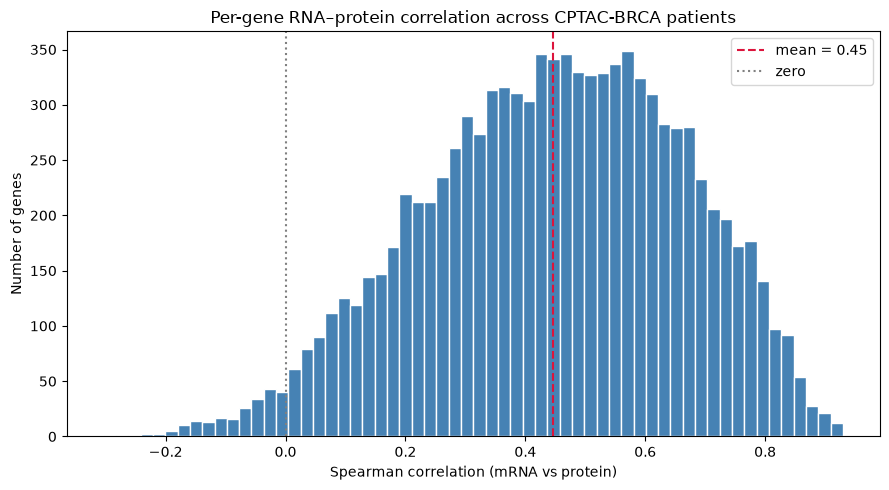

In [11]:
plt.figure(figsize=(9, 5))

plt.hist(gene_corr.dropna(), bins=60, color="steelblue", edgecolor="white")

# Reference lines: mean, and zero
plt.axvline(gene_corr.mean(), color="crimson", linestyle="--",
            label=f"mean = {gene_corr.mean():.2f}")
plt.axvline(0, color="grey", linestyle=":", label="zero")

plt.xlabel("Spearman correlation (mRNA vs protein)")
plt.ylabel("Number of genes")
plt.title("Per-gene RNA–protein correlation across CPTAC-BRCA patients")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation.** The distribution is a slightly left-skewed bell centered near 0.45.
Most genes show positive mRNA–protein coupling; the tail crossing zero holds the post-transcriptional regulation candidates. The smooth, artifact-free shape indicates
a clean pipeline.

## Top post-transcriptional regulation candidates

We rank genes by lowest RNA–protein correlation. These are the genes whose protein level is least explained by their mRNA — the strongest candidates for post-transcriptional regulation.

In [12]:
# Genes with the weakest RNA-protein coupling = top candidates
candidates = gene_corr.sort_values().head(20)
print("="*50 + f"\n Top 20 post-transcriptional regulation candidates \n(lowest RNA-protein Spearman correlation) \n" + "="*50)

display(candidates.to_frame(name="Spearman r"))

 Top 20 post-transcriptional regulation candidates 
(lowest RNA-protein Spearman correlation) 


,Spearman r
Name,
DDN,-0.303485
CCDC150,-0.273067
SNX32,-0.230788
AHSG,-0.222342
F12,-0.216983
APOC1,-0.202881
GC,-0.196934
PSMB7,-0.192644
HGFAC,-0.190579


**Interpretation.** These genes have the weakest mRNA-protein coupling, making them the strongest candidates for post-transcriptional regulation,  with the caveat noted below.

# Note on secreted / plasma proteins

Some top candidates (e.g. **AHSG, F12, GC, APOC1, PROZ, HGFAC, CFHR5**) are secreted proteins of mainly **hepatic / plasma origin**. Their low mRNA-protein correlation in tumor tissue does **not** reflect post-transcriptional regulation: these proteins are produced elsewhere (largely the liver) and carried into the tumor via blood, so their protein level is decoupled *by construction* from local tumor mRNA. This is a known confounder in tumor proteogenomics. We keep them in the ranking for transparency and flag them here rather than removing them with an external gene list.

# 4 - Per-sample protein-to-RNA deviation (PTR)

The correlation above is a *per-gene* summary across patients. The PTR is the complementary *per-patient* view: for a given gene in a given tumor, does it carry more or less protein than its mRNA would predict? To compare mRNA and protein on a common scale, we z-score each gene across patients, then take `PTR = protein_z − mRNA_z`.
A positive PTR means relatively more protein than expected from mRNA; negative means less.

In [13]:
# Standardize each gene across patients (needed to compare mRNA and protein directly)
rna_z = (rna_common - rna_common.mean()) / rna_common.std()
prot_z = (prot_common - prot_common.mean()) / prot_common.std()

# Per-sample protein-to-RNA deviation
ptr = prot_z - rna_z

print("PTR matrix:", ptr.shape, "(patients × genes)")
display(ptr.iloc[:5, :5])

PTR matrix: (121, 9833) (patients × genes)


Name,A1BG,A2M,A2ML1,AAAS,AACS
Patient_ID,,,,,
01BR001,0.965974,1.315739,-0.702269,1.249374,-0.094362
01BR008,-0.616957,0.410914,-0.463162,-0.299632,-0.473149
01BR009,-1.047307,1.307577,0.076442,-1.192907,-0.668719
01BR010,-1.787224,-0.220249,-0.974576,0.068785,-0.409137
01BR015,-0.167192,-0.784251,-0.382377,0.693562,-0.153904


## Example: which patients deviate most for a well-coupled gene?

For a gene whose protein normally tracks mRNA well (high correlation), the PTR highlights the few patients whose protein departs from that expectation, the outlier tumors worth a closer look.

In [14]:
# Pick a well-correlated gene (protein usually tracks mRNA)
example_gene = gene_corr.sort_values(ascending=False).index[0]
print(f"Example gene: {example_gene} (Spearman r = {gene_corr[example_gene]:.2f})\n")

# Patients with the largest absolute PTR for this gene
gene_ptr = ptr[example_gene].sort_values(key=abs, ascending=False)
print("Patients deviating most (protein vs mRNA expectation):")
display(gene_ptr.head(5).to_frame(name=f"PTR ({example_gene})"))

Example gene: C1orf116 (Spearman r = 0.93)

Patients deviating most (protein vs mRNA expectation):


,PTR (C1orf116)
Patient_ID,
01BR030,2.060507
14BR005,1.567690
11BR025,1.485855
09BR004,1.317199
01BR023,1.169589


**Interpretation.** Even for a strongly coupled gene (r = 0.93), a few tumors deviate markedly (e.g. 01BR030, PTR ≈ +2), carrying more protein than their mRNA predicts.
The correlation flags globally regulated genes; the PTR flags individual tumors that break the expected pattern, the two views are complementary.

# Section 5 - Does genomics (CNV) improve protein prediction beyond mRNA?

Correlation only relates mRNA to protein, one-to-one. Here we ask a multivariate question: does adding a gene's copy-number (CNV) help predict its protein level beyond mRNA alone? We compare, under cross-validation, a model using **mRNA only** against a model using **mRNA + CNV**, always evaluating on held-out patients.

In [15]:
cnv = brca.get_CNV(source="washu")
cnv.columns = cnv.columns.get_level_values("Name")

print("CNV shape:", cnv.shape)
display(cnv.iloc[:5, :5])

CNV shape: (122, 18926)


F:\BD\ptr-proteogenomics-brca\.venv\Lib\site-packages\cptac\cancers\washu\washubrca.py:160: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.reset_index()


Name,A1BG,A1CF,A2M,A2ML1,A3GALT2
Patient_ID,,,,,
01BR001,-0.07265,-0.00966,-0.11622,-0.11622,0.81754
01BR008,-0.06644,0.11550,0.31413,0.31413,0.08417
01BR009,0.28468,-0.14743,-0.26372,-0.26372,-0.13078
01BR010,0.00370,-0.14666,-0.00332,-0.00332,0.03008
01BR015,0.09610,0.13746,0.03751,0.03751,-0.17893


### Align CNV with the working cohort

We restrict CNV to the same 121 patients and the same filtered genes, so mRNA, CNV and protein are all superimposable.

In [16]:
# Genes shared by mRNA/protein set and CNV
cnv_genes = [g for g in keep_genes if g in cnv.columns]

# Patients shared by our cohort and CNV (washu covers a slightly different set)
cnv_patients = rna_common.index.intersection(cnv.index)

cnv_common = cnv.loc[cnv_patients, cnv_genes]

print("CNV aligned:", cnv_common.shape)
print("Patients shared across all omics:", len(cnv_patients))
print("Genes shared across all omics:", len(cnv_genes))

CNV aligned: (119, 8995)
Patients shared across all omics: 119
Genes shared across all omics: 8978


### Compare mRNA-only vs mRNA+CNV, per gene, under cross-validation

For a random sample of genes, we train a Random Forest to predict protein from (A) mRNA
only and (B) mRNA + CNV, scoring each with 5-fold cross-validation (R² on held-out
patients). We then compare the two models across genes.

In [17]:
# Reproducible random sample of genes (fast, representative PoC)
rng = np.random.default_rng(42)
sample_genes = rng.choice(cnv_genes, size=300, replace=False)

# Align all three omics on the shared patients
rna_ml = rna_common.loc[cnv_patients]
prot_ml = prot_common.loc[cnv_patients]
cnv_ml = cnv_common  # already on cnv_patients

results = []

for gene in sample_genes:
    y = prot_ml[gene]
    mask = y.notna()
    if mask.sum() < 80:            # enough patients to cross-validate
        continue

    y_g = y[mask]
    rna_g = rna_ml.loc[mask, [gene]]
    cnv_g = cnv_ml.loc[mask, [gene]]

    X_a = rna_g                                  # model A: mRNA only
    X_b = np.column_stack([rna_g, cnv_g])        # model B: mRNA + CNV

    model = RandomForestRegressor(n_estimators=100, random_state=0)

    r2_a = cross_val_score(model, X_a, y_g, cv=5, scoring="r2").mean()
    r2_b = cross_val_score(model, X_b, y_g, cv=5, scoring="r2").mean()

    results.append({"gene": gene, "R2_rna": r2_a, "R2_rna_cnv": r2_b})

results = pd.DataFrame(results)
print(f"Genes evaluated: {len(results)}")
display(results.head())

Genes evaluated: 282


,gene,R2_rna,R2_rna_cnv
0,MICU1,-0.093397,-0.054323
1,SDF2,-0.802910,-0.328158
2,CCDC149,-0.235323,-0.131760
3,BHLHE40,0.329485,0.255180
4,PCCB,-0.748731,-0.239593


### Does CNV help, overall?

We summarize across all evaluated genes: the average R² of each model, and the share of genes where adding CNV improves the held-out R².

In [18]:
results["gain"] = results["R2_rna_cnv"] - results["R2_rna"]

print("Mean R² (mRNA only) :", round(results["R2_rna"].mean(), 3))
print("Mean R² (mRNA + CNV):", round(results["R2_rna_cnv"].mean(), 3))
print("Mean gain from CNV  :", round(results["gain"].mean(), 3))
print()
print("Genes improved by CNV:",
      f"{(results['gain'] > 0).mean():.0%} of {len(results)}")

Mean R² (mRNA only) : -0.218
Mean R² (mRNA + CNV): -0.024
Mean gain from CNV  : 0.194

Genes improved by CNV: 93% of 282


**Interpretation.** Adding CNV improves held-out R² for **93% of genes** (mean gain ≈ +0.19), showing that copy-number carries protein-level information beyond mRNA, a multivariate signal the correlation analysis cannot capture.

Note that both models have **negative absolute R²**: with ~119 patients, a per-gene Random Forest cannot reliably predict protein in absolute terms. The meaningful result here is **relative** — at equal data, genomics consistently helps — not the absolute predictive accuracy.

### Visualizing the CNV gain

Each point is a gene: x = R² with mRNA only, y = R² with mRNA + CNV. Points **above the diagonal** are genes where CNV improves prediction. The bulk sitting above the line shows the effect is systematic.

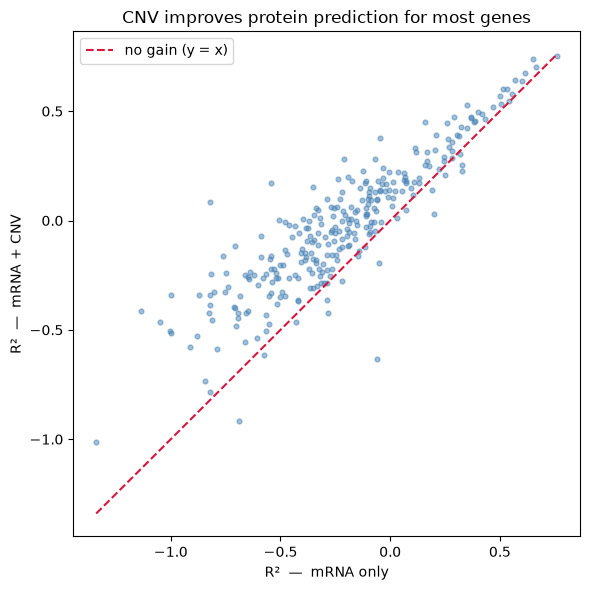

In [20]:
plt.figure(figsize=(6, 6))

plt.scatter(results["R2_rna"], results["R2_rna_cnv"],
            s=12, alpha=0.5, color="steelblue")

# Diagonal y = x : above it = CNV helps
lims = [results[["R2_rna", "R2_rna_cnv"]].min().min(),
        results[["R2_rna", "R2_rna_cnv"]].max().max()]
plt.plot(lims, lims, "--", color="crimson", label="no gain (y = x)")

plt.xlabel("R²  —  mRNA only")
plt.ylabel("R²  —  mRNA + CNV")
plt.title("CNV improves protein prediction for most genes")
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion

Using matched transcriptomics, proteomics and copy-number data from CPTAC-BRCA tumors,
we characterized post-transcriptional regulation from three complementary angles:

- **Per gene — RNA–protein correlation.** Spearman correlation across patients (mean
  ≈ 0.45, consistent with CPTAC literature) identifies genes whose protein is decoupled
  from mRNA. Some low-correlation genes are secreted proteins of extra-tumoral origin
  rather than genuine post-transcriptional regulation — a documented confounder.
- **Per patient — protein-to-RNA deviation (PTR).** The standardized PTR flags individual
  tumors that depart from a gene's usual mRNA–protein relationship, even for well-coupled
  genes.
- **Multivariate — does genomics add information?** A cross-validated Random Forest shows
  that adding copy-number (CNV) improves held-out protein prediction for **93%** of genes
  (mean R² gain ≈ +0.19). Absolute R² stays low (~119 patients, per-gene models), so the
  meaningful result is the **relative** gain: genomics carries protein-level signal beyond
  mRNA — something the correlation cannot capture.

Together, these views separate *which genes* are post-transcriptionally regulated, *which
tumors* break the expected pattern, and *whether genomic dosage* helps explain protein
levels. The pipeline is fully self-contained (public CPTAC data, no external annotation)
and reproduces a known proteogenomic benchmark. Natural extensions include pathway
enrichment of candidate genes, filtering secreted proteins, and larger feature sets
(methylation, mutations) for the predictive model.